In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10,6)


print("Libraries imported successfully")

Libraries imported successfully


In [7]:
df = pd.read_csv('../data/raw/telco_churn.csv')
pd.set_option('display.max_rows',7043)
pd.set_option('display.max_column',21)
print("Data loaded successfully")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded successfully
Dataset shape: 7043 rows, 21 columns


In [13]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
print("Dataset Information")
print("-"*50)
df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-nu

In [16]:
print("Summary")
df.describe()

Summary


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [24]:
print("Missing values in each column")
print(df.isnull().sum())
print("-"*50)
print(f"Total missing values: {df.isnull().sum().sum()}")

Missing values in each column
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
--------------------------------------------------
Total missing values: 0


In [26]:
print("All column names")
df.columns

All column names


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [29]:
#churn values
print("Churn Distribution")
print(df['Churn'].value_counts())
print("-"*50)
#precentage distribution
print("Churn Percentage")
churn_pct = df['Churn'].value_counts(normalize=True) * 100 
#the normalize helps to return proortions
print(churn_pct)

Churn Distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64
--------------------------------------------------
Churn Percentage
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


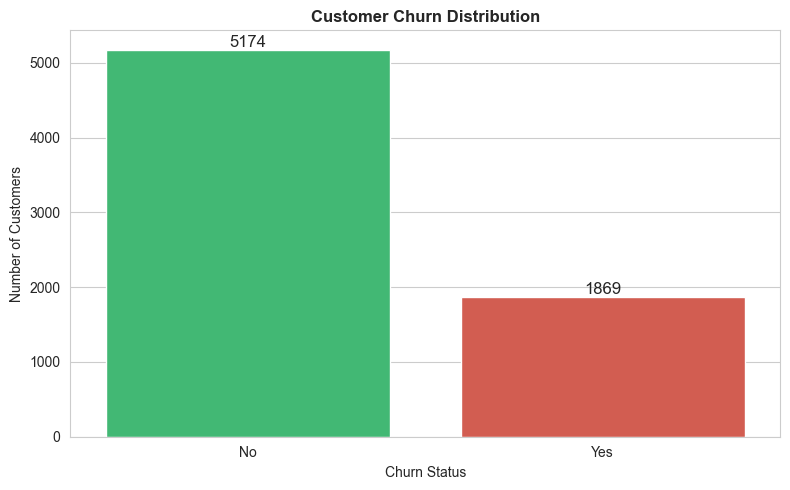

Chart saved: visualizations/churn_distribution.png


In [56]:
#churn chart
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Churn',palette=['#2ecc71', '#e74c3c'],hue='Churn',legend=False)
plt.title("Customer Churn Distribution",fontsize=12,fontweight='bold')
plt.xlabel("Churn Status",fontsize=10)
plt.ylabel("Number of Customers",fontsize=10)

#value labels
for container in plt.gca().containers:
    plt.gca().bar_label(container,fontsize=12)

plt.tight_layout()
plt.savefig('../visualizations/churn_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

print("Chart saved: visualizations/churn_distribution.png")

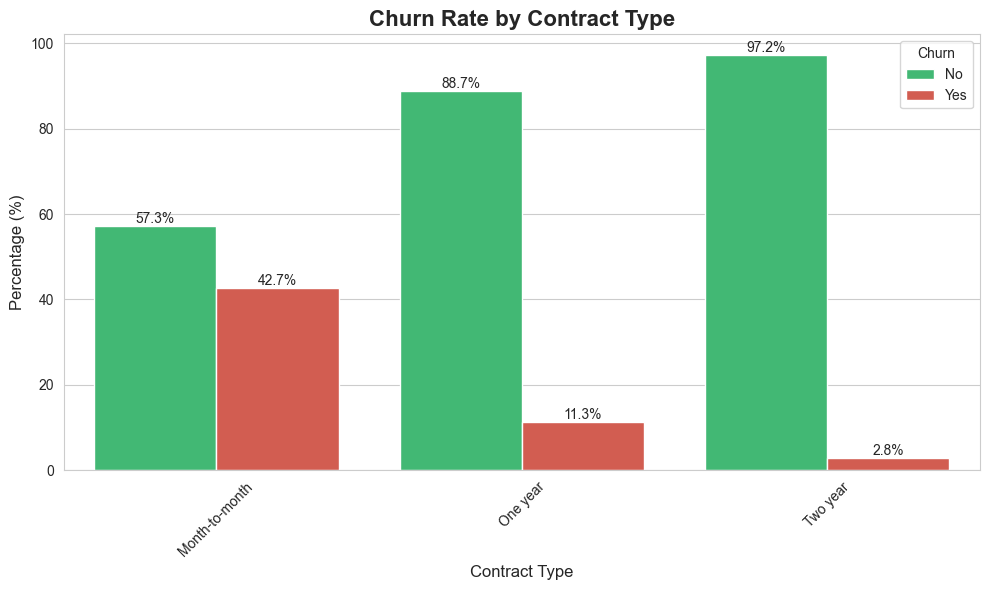

Chart saved: visualizations/churn_by_contract.png


In [70]:
plt.figure(figsize=(10,6))
contract_pct = (
    pd.crosstab(df['Contract'], df['Churn'], normalize='index')
    .mul(100)
    .reset_index()
)
contract_pct = contract_pct.melt(
    id_vars='Contract',
    var_name='Churn',
    value_name='Percentage'
)
ax = sns.barplot(
    data=contract_pct,
    x='Contract',
    y='Percentage',
    hue='Churn',
    palette=['#2ecc71', '#e74c3c']
)

plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Churn', loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.savefig('../visualizations/churn_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: visualizations/churn_by_contract.png")

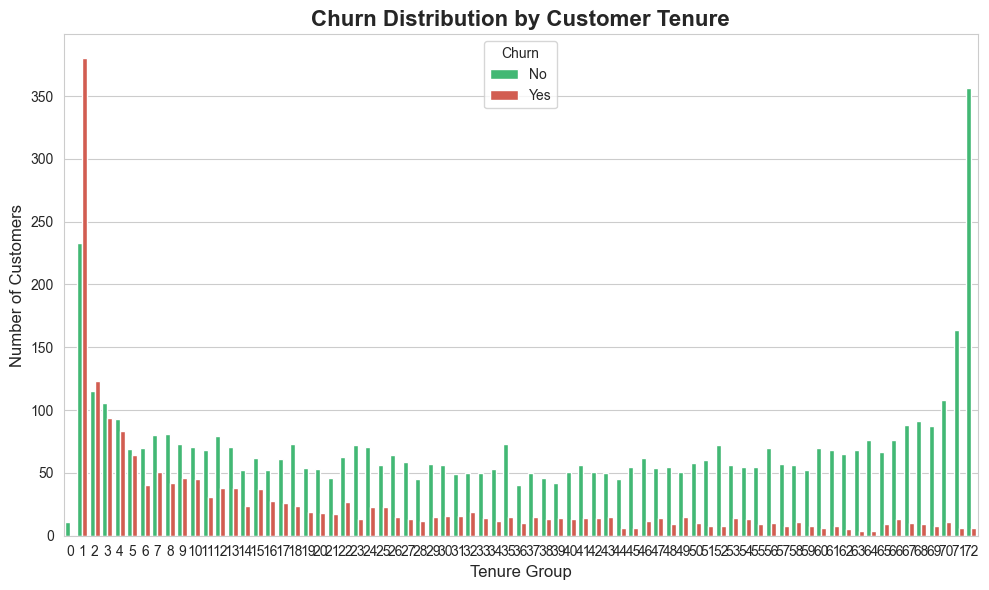

Chart saved: visualizations/churn_by_tenure.png


In [71]:
#tenure vs churn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='tenure', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution by Customer Tenure', fontsize=16, fontweight='bold')
plt.xlabel('Tenure Group', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn', labels=['No', 'Yes'])

plt.tight_layout()
plt.savefig('../visualizations/churn_by_tenure.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: visualizations/churn_by_tenure.png")

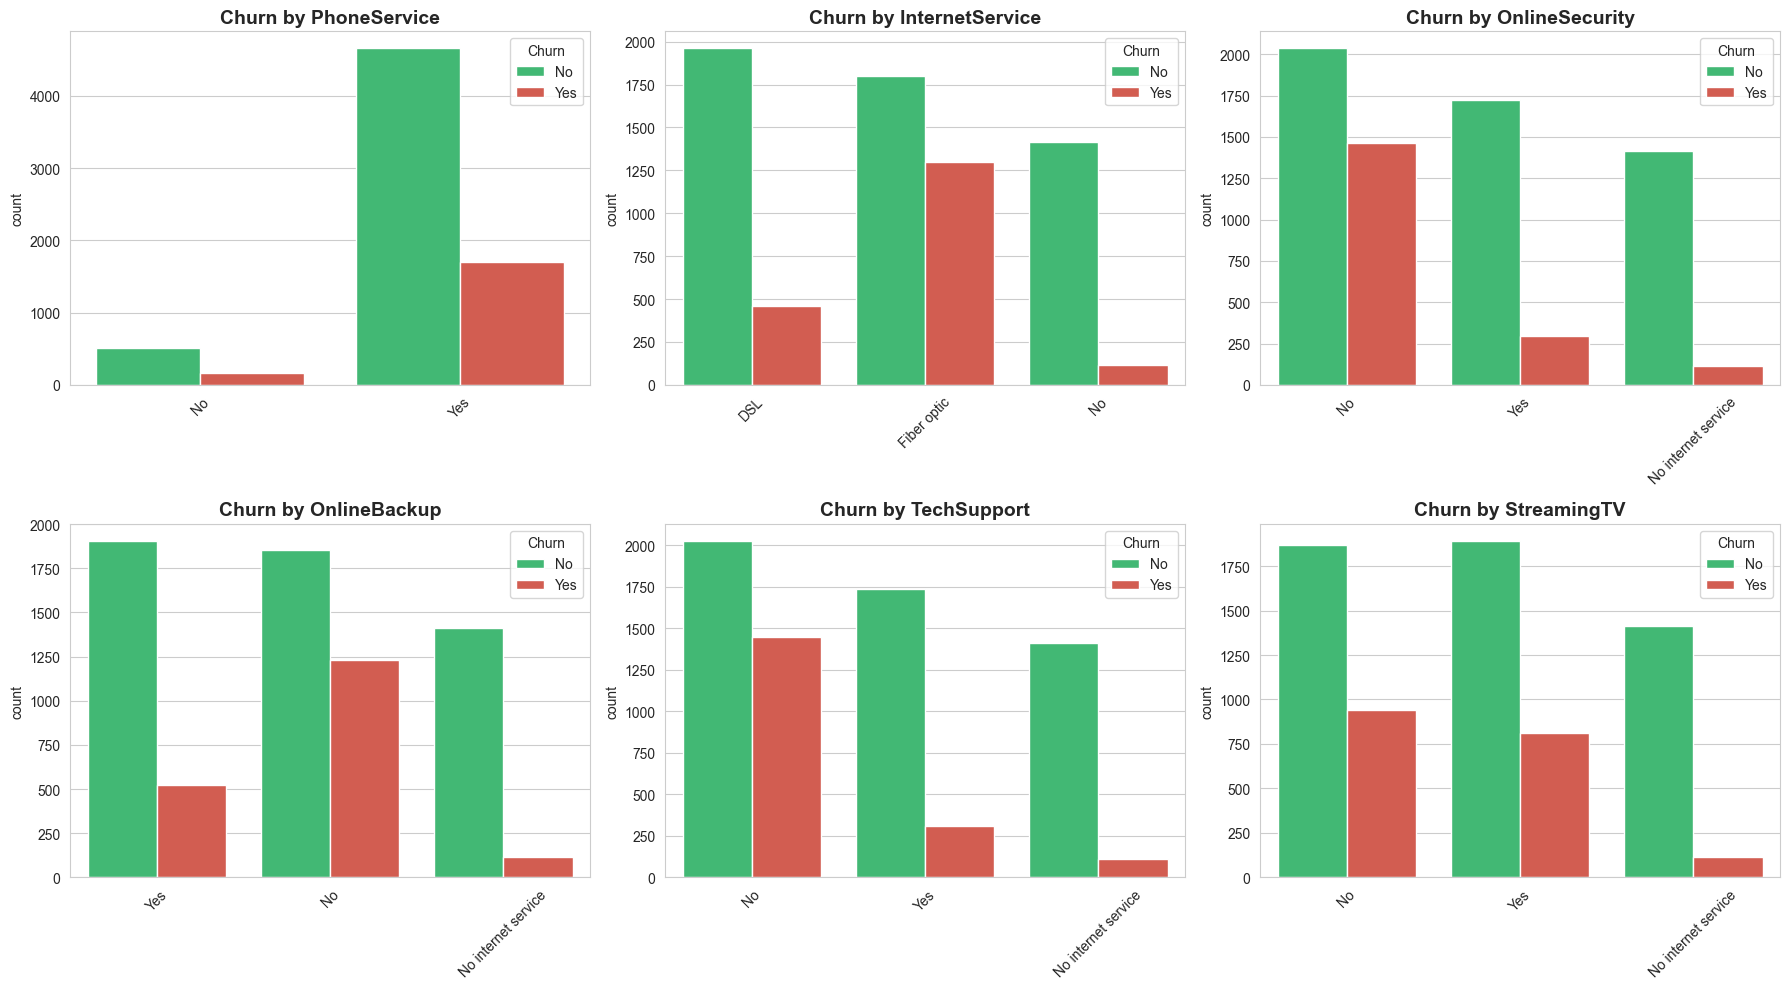

Chart saved: visualizations/churn_by_services.png


In [72]:
# List of service columns
services = ['PhoneService', 'InternetService', 'OnlineSecurity', 
            'OnlineBackup', 'TechSupport', 'StreamingTV']

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, service in enumerate(services):
    sns.countplot(data=df, x=service, hue='Churn', 
                  palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'Churn by {service}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(title='Churn', labels=['No', 'Yes'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../visualizations/churn_by_services.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: visualizations/churn_by_services.png")

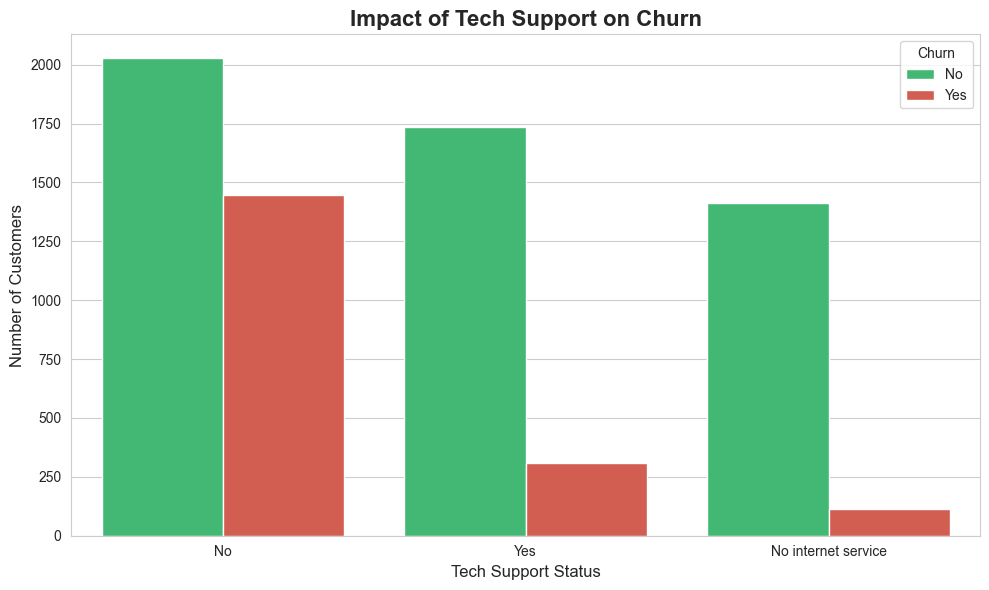


Churn Rate by Tech Support (%):
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


In [80]:
#techsupport deep dive
tech_churn = pd.crosstab(df['TechSupport'],df['Churn'],normalize='index')*100
#crosstab(rows,column) shows raw counts
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='TechSupport', hue='Churn', 
            palette=['#2ecc71', '#e74c3c'])
plt.title('Impact of Tech Support on Churn', fontsize=16, fontweight='bold')
plt.xlabel('Tech Support Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn', labels=['No', 'Yes'])

plt.tight_layout()
plt.savefig('../visualizations/churn_by_techsupport.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChurn Rate by Tech Support (%):")
print(tech_churn)

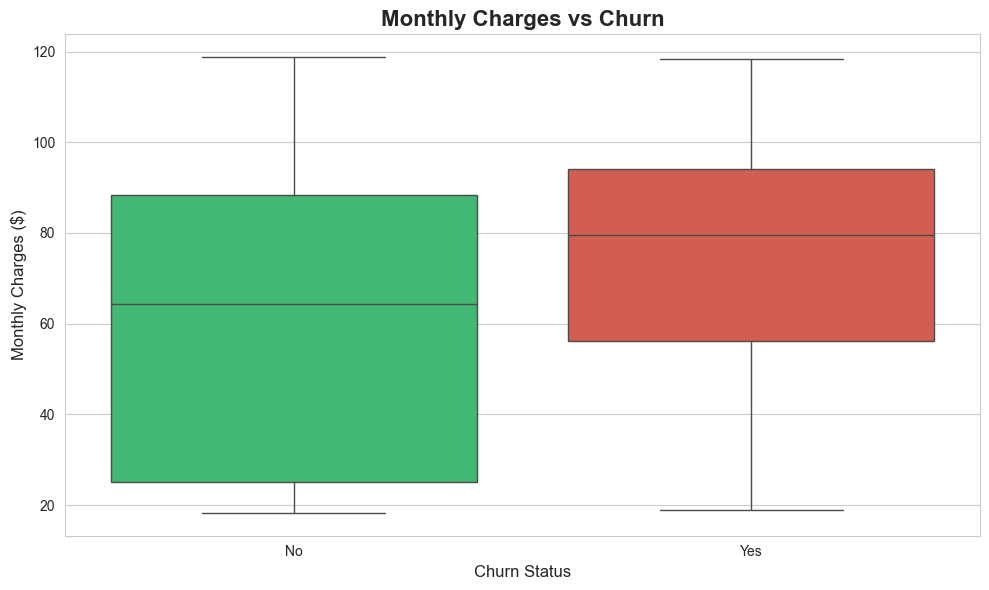


Average Monthly Charges:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [94]:
#charge distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn',legend=False,
            palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges vs Churn', fontsize=16, fontweight='bold')
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)

plt.tight_layout()
plt.savefig('../visualizations/monthly_charges_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate averages
print("\nAverage Monthly Charges:")
print(df.groupby('Churn')['MonthlyCharges'].mean())

In [98]:
#labelencoding - it is referred to giving numeric values to string types
#like Yes-1,No-0 we can use the map() method also but for a large dataset a function creation
#would help a lot
#this will work with sklearn module

In [67]:
# Create a copy for encoding
df_numeric = df.copy()

print("Starting encoding process...")
print("-"*50)

# 1. Convert Yes/No columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 
               'Churn', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
               'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    if col in df_numeric.columns:
        df_numeric[col] = df_numeric[col].map({'Yes': 1, 'No': 0})
        print(f"{col}: Yes=1, No=0")

# 2. Convert Gender
df_numeric['gender'] = df_numeric['gender'].map({'Male': 0, 'Female': 1})
print(f"gender: Male=0, Female=1")

# 3. Convert Contract Type
df_numeric['Contract'] = df_numeric['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})
print(f"Contract: Month-to-month=0, One year=1, Two year=2")

# 4. Convert Internet Service
df_numeric['InternetService'] = df_numeric['InternetService'].map({
    'No': 0,
    'DSL': 1,
    'Fiber optic': 2
})
print(f"InternetService: No=0, DSL=1, Fiber optic=2")

# 5. Convert Payment Method
df_numeric['PaymentMethod'] = df_numeric['PaymentMethod'].map({
    'Electronic check': 0,
    'Mailed check': 1,
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 3
})
print(f"PaymentMethod: Electronic check=0, Mailed check=1, Bank transfer=2, Credit card=3")

# 6. Convert MultipleLines (if it exists)
if 'MultipleLines' in df_numeric.columns:
    df_numeric['MultipleLines'] = df_numeric['MultipleLines'].map({
        'No phone service': 0,
        'No': 1,
        'Yes': 2
    })
    print(f"MultipleLines: No phone service=0, No=1, Yes=2")

print("-"*50)
print("All text columns converted to numbers!")



numeric_data = df_numeric.select_dtypes(include=[np.number])

print(f"\nTotal numeric columns: {len(numeric_data.columns)}")
print("Numeric columns:")
print(numeric_data.columns.tolist())

Starting encoding process...
--------------------------------------------------
Partner: Yes=1, No=0
Dependents: Yes=1, No=0
PhoneService: Yes=1, No=0
PaperlessBilling: Yes=1, No=0
Churn: Yes=1, No=0
OnlineSecurity: Yes=1, No=0
OnlineBackup: Yes=1, No=0
DeviceProtection: Yes=1, No=0
TechSupport: Yes=1, No=0
StreamingTV: Yes=1, No=0
StreamingMovies: Yes=1, No=0
gender: Male=0, Female=1
Contract: Month-to-month=0, One year=1, Two year=2
InternetService: No=0, DSL=1, Fiber optic=2
PaymentMethod: Electronic check=0, Mailed check=1, Bank transfer=2, Credit card=3
MultipleLines: No phone service=0, No=1, Yes=2
--------------------------------------------------
All text columns converted to numbers!

Total numeric columns: 19
Numeric columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'Pay

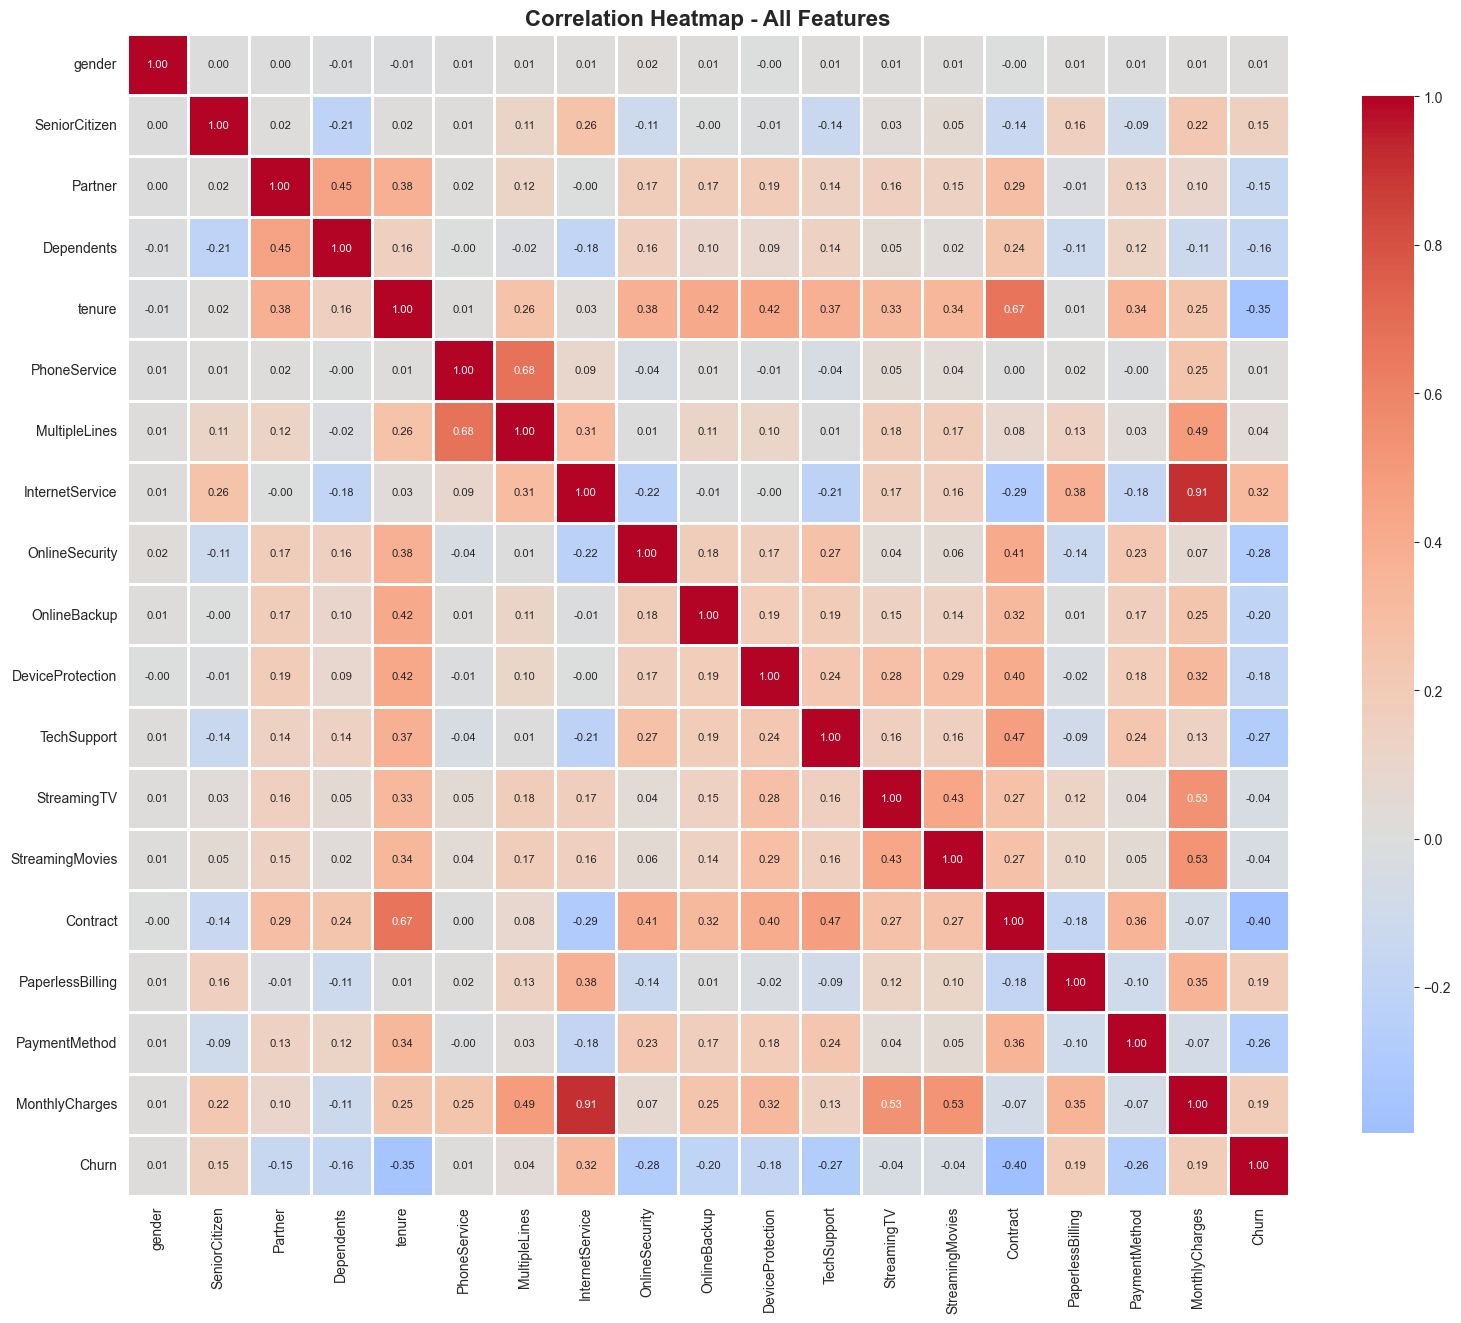

Chart saved: visualizations/correlation_heatmap.png


In [68]:
#correlation heatmap
plt.figure(figsize=(16,14))
correlation_matrix=numeric_data.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, 
            square=True, linewidths=1, 
            cbar_kws={"shrink": 0.8},
            annot_kws={"fontsize": 8})
plt.title('Correlation Heatmap - All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: visualizations/correlation_heatmap.png")

In [69]:
#correlations with churn
churn_correlation = correlation_matrix['Churn'].sort_values(ascending=False)

print("Top 10 features correlated with churn")
print("-"*50)
print(churn_correlation.head(11))
print("\n")
print("Bottom 5 features")
print("-"*50)
print(churn_correlation.tail(5))

Top 10 features correlated with churn
--------------------------------------------------
Churn               1.000000
InternetService     0.316846
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
MultipleLines       0.036310
PhoneService        0.011942
gender              0.008612
StreamingTV        -0.037057
StreamingMovies    -0.040132
Partner            -0.150448
Name: Churn, dtype: float64


Bottom 5 features
--------------------------------------------------
PaymentMethod    -0.262818
TechSupport      -0.274422
OnlineSecurity   -0.280816
tenure           -0.352229
Contract         -0.396713
Name: Churn, dtype: float64


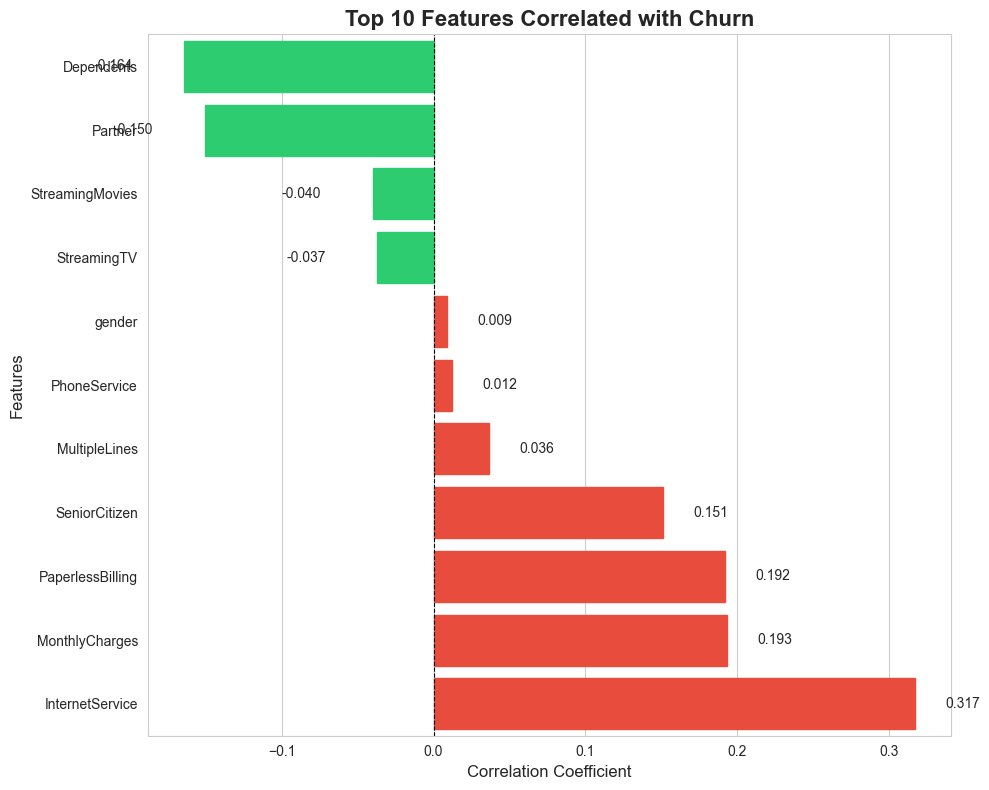

Chart saved: visualizations/top_correlations.png


In [124]:
plt.figure(figsize=(10, 8))
top_corr = churn_correlation.drop(['Churn_numeric','Churn'])[0:11]
top_corr = top_corr.sort_values()
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_corr]

ax = sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
    orient='h'
)

# Apply colors manually
for bar, color in zip(ax.patches, colors):
    bar.set_color(color)

plt.title('Top 10 Features Correlated with Churn', fontsize=16, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# Better label positioning
for i, v in enumerate(top_corr.values):
    ax.text(
        v + 0.02 if v > 0 else v - 0.06,
        i,
        f'{v:.3f}',
        va='center'
    )

plt.tight_layout()
plt.savefig('../visualizations/top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: visualizations/top_correlations.png")

In [1]:
#Summary


In [23]:
print("EDA Summary Report")
print("-"*50)
print(f"Total Customers: {len(df)}")
print(f"Total Features: {df.shape[1]}")
print(f"Churned Customers: {len(df[df['Churn'] == 'Yes'])}")
print(f"Retained Customers: {len(df[df['Churn'] == 'No'])}")
print(f"Overall Churn Rate: {(len(df[df['Churn'] == 'Yes'])/len(df)*100):.2f}%")

#Missing value
print("\nData Quality")
print("-"*70)
missing_count = df.isnull().sum().sum()
print(f"Missing Values: {missing_count}")
print(f"Duplicate Rows: {df.duplicated().sum()}") #duplicated check the duplicate rows
print(f"Data Quality: {'Excellent' if missing_count < 100 else 'Needs Attention'}")

EDA Summary Report
--------------------------------------------------
Total Customers: 7043
Total Features: 21
Churned Customers: 1869
Retained Customers: 5174
Overall Churn Rate: 26.54%

Data Quality
----------------------------------------------------------------------
Missing Values: 0
Duplicate Rows: 0
Data Quality: Excellent


In [95]:
print("Key Findings")
print("-"*20)

#contract insight
contract_churn = pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100
mtm_churn = contract_churn.loc['Month-to-month','Yes']
one_yr_churn = contract_churn.loc['One year','Yes']
two_yr_churn = contract_churn.loc['Two year','Yes']

print("\nKey Insight: Contract Type")
print("-"*50)
print(f"Month-to-month churn rate: {mtm_churn:.1f}%")
print(f"One year churn rate: {one_yr_churn:.1f}%")
print(f"Two year churn rate: {two_yr_churn:.1f}%")
print(f"Risk Ratio: {mtm_churn/two_yr_churn:.1f}x higher for month-to-month")
print("CONTRACT TYPE IS CRITICAL")

#tenure
tenure_churn = pd.crosstab(df['tenure'],df['Churn'],normalize='index')*100
new_churn = tenure_churn.loc[tenure_churn.index <= 12,'Yes'].mean()
mid_churn = tenure_churn.loc[(tenure_churn.index >=12) & (tenure_churn.index < 24),'Yes'].mean()
loyal_churn = tenure_churn.loc[tenure_churn.index >= 24,'Yes'].mean()

print("\nKey Insight: Tenure")
print("-"*50)
print(f"0-1 year customers churn rate: {new_churn:.1f}%")
print(f"1-2 year customers churn rate: {mid_churn:.1f}%")
print(f"2+ years customers churn rate: {loyal_churn:.1f}%")
print(f"Risk Ratio: {new_churn/loyal_churn:.1f}x higher for new customers")
print("NEW CUSTOMERS ARE HIGH RISK")
#

#charge insight
avg_churn=df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_stay=df[df['Churn'] == 'No']['MonthlyCharges'].mean()

print("\nKey Insight: Monthly Charges")
print("-"*50)
print(f"Churned customers average: ${avg_churn:.2f}/month")
print(f"Retained customers average: ${avg_stay:.2f}/month")
print(f"Hence, churned customers pay ${avg_churn - avg_stay:.2f} MORE per month!")
print("PRICING MATTERS")

#service insight or tech support impact
tech_churn =pd.crosstab(df['TechSupport'],df['Churn'],normalize='index')*100
no_tech_churn = tech_churn.loc['No','Yes'] #.loc(TechSupport,Churn)
yes_tech_churn = tech_churn.loc['Yes','Yes']

print("\nKey Insight: Tech Support Impact")
print("-"*50)
print(f"Without tech support chrun rate: {no_tech_churn:.1f}%")
print(f"With tech support chrun rate: {yes_tech_churn:.1f}%")
print(f"Hence, xustomers without tech support are {no_tech_churn/yes_tech_churn:.1f}% times more likely to churn!")
print("TECH SUPPORT MATTERS")

#Internet Service Type
internet_churn = pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100
fiber_churn = internet_churn.loc['Fiber optic','Yes']
dsl_churn = internet_churn.loc['DSL','Yes']
no_internet_churn = internet_churn.loc['No','Yes']

print("\nKey Insight: Internet Service Type")
print("-"*50)
print(f"Fiber optic churn rate: {fiber_churn:.1f}%")
print(f"DSL churn rate: {dsl_churn:.1f}%")
print(f"No internet churn rate: {no_internet_churn:.1f}%")
risk_ratio = fiber_churn / dsl_churn
print(f"Hence, fiber optic customers are {risk_ratio:.1f} times more likely to churn!")
print("FIBER OPTIC SERVICE NEEDS ATTENTION")

Key Findings
--------------------

Key Insight: Contract Type
--------------------------------------------------
Month-to-month churn rate: 42.7%
One year churn rate: 11.3%
Two year churn rate: 2.8%
Risk Ratio: 15.1x higher for month-to-month
CONTRACT TYPE IS CRITICAL

Key Insight: Tenure
--------------------------------------------------
0-1 year customers churn rate: 39.0%
1-2 year customers churn rate: 29.1%
2+ years customers churn rate: 16.0%
Risk Ratio: 2.4x higher for new customers
NEW CUSTOMERS ARE HIGH RISK

Key Insight: Monthly Charges
--------------------------------------------------
Churned customers average: $74.44/month
Retained customers average: $61.27/month
Hence, churned customers pay $13.18 MORE per month!
PRICING MATTERS

Key Insight: Tech Support Impact
--------------------------------------------------
Without tech support chrun rate: 41.6%
With tech support chrun rate: 15.2%
Hence, xustomers without tech support are 2.7% times more likely to churn!
TECH SUPPORT 

In [62]:
print("BUSINESS RECOMMENDATIONS")
print("-"*40)

print("\nRECOMMENDATION #1: CONTRACT INCENTIVES")
print("-"*50)
print("   Action: Offer 15-20% discount for customers switching to annual contracts")
print("   Target: Month-to-month customers")
print("   Expected Impact: Reduce churn by 15-20%")
print("   Estimated Savings: High-value implementation")

print("\nRECOMMENDATION #2: NEW CUSTOMER WELCOME PROGRAM")
print("-"*50)
print("   Action: Implement 6-month onboarding program with extra support")
print("   Target: Customers in first year")
print("   Expected Impact: Reduce early churn by 25%")
print("   Components:")
print("      Regular check-in calls")
print("      Free premium support for 3 months")
print("      Usage optimization tips")

print("\nRECOMMENDATION #3: SERVICE BUNDLES")
print("-"*50)
print("   Action: Bundle Tech Support + Online Security as retention package")
print("   Target: At-risk customers without these services")
print("   Expected Impact: Reduce churn by 30% in target group")
print("   Pricing: Offer bundle at 20% discount")

print("\nRECOMMENDATION #4: PRICING REVIEW")
print("-"*50)
print("   Action: Review pricing for high-paying customers")
print("   Target: Customers paying >$80/month")
print("   Expected Impact: Improve price satisfaction, reduce price-driven churn")
print("   Options:")
print("      Loyalty discounts for long-term customers")
print("      Value-added services at no extra cost")

print("\nRECOMMENDATION #5: FIBER OPTIC SERVICE QUALITY")
print("-"*50)
print("   Action: Urgent investigation of fiber optic service quality issues")
print("   Target: All fiber optic customers")
print("   Expected Impact: Save 400+ high-value customers annually")
print("   Steps:")
print("      Service quality audit")
print("      Speed/reliability improvements")
print("      Proactive customer communication")

BUSINESS RECOMMENDATIONS
----------------------------------------

RECOMMENDATION #1: CONTRACT INCENTIVES
--------------------------------------------------
   Action: Offer 15-20% discount for customers switching to annual contracts
   Target: Month-to-month customers
   Expected Impact: Reduce churn by 15-20%
   Estimated Savings: High-value implementation

RECOMMENDATION #2: NEW CUSTOMER WELCOME PROGRAM
--------------------------------------------------
   Action: Implement 6-month onboarding program with extra support
   Target: Customers in first year
   Expected Impact: Reduce early churn by 25%
   Components:
      Regular check-in calls
      Free premium support for 3 months
      Usage optimization tips

RECOMMENDATION #3: SERVICE BUNDLES
--------------------------------------------------
   Action: Bundle Tech Support + Online Security as retention package
   Target: At-risk customers without these services
   Expected Impact: Reduce churn by 30% in target group
   Pricing: 

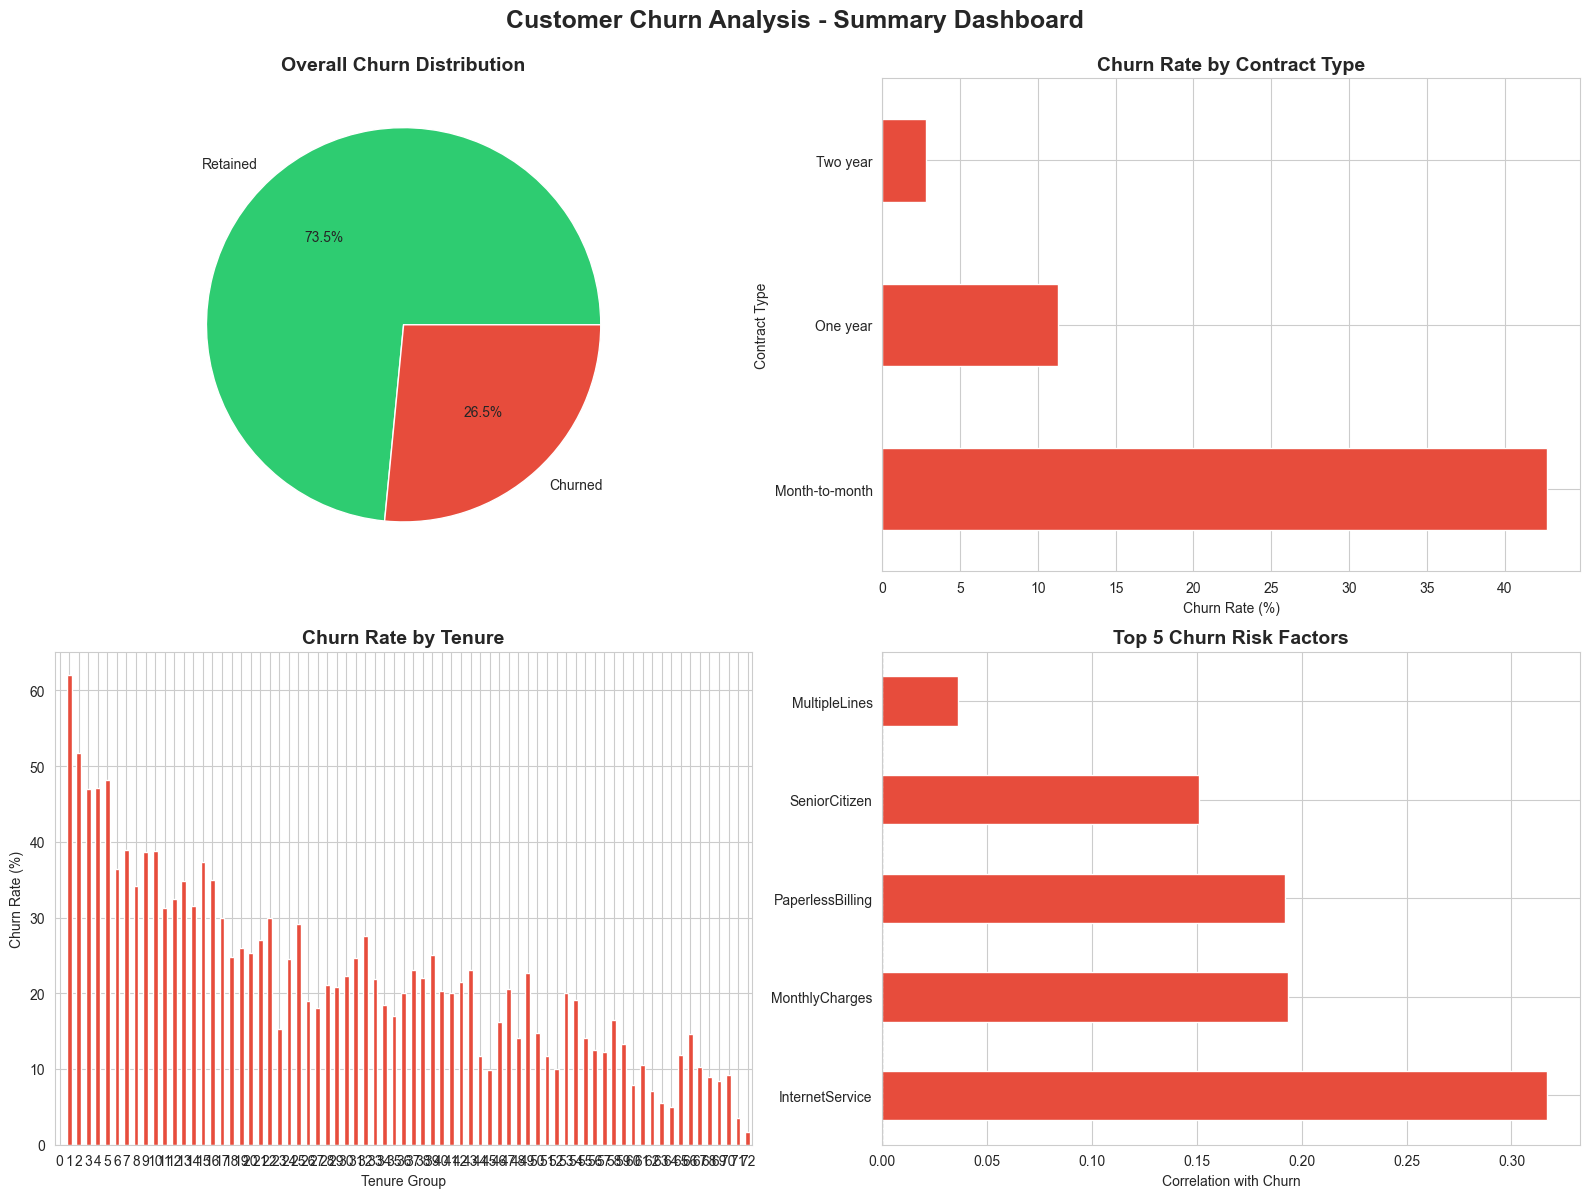

Summary dashboard saved: visualizations/summary_dashboard.png


In [71]:
#summary visualization with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Churn Distribution
ax1 = axes[0, 0]
df['Churn'].value_counts().plot(kind='pie', ax=ax1, autopct='%1.1f%%', 
                                 colors=['#2ecc71', '#e74c3c'], 
                                 labels=['Retained', 'Churned'])
ax1.set_title('Overall Churn Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('')

#Contract Type Impact
ax2 = axes[0, 1]
contract_data = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_data['Yes'].plot(kind='barh', ax=ax2, color='#e74c3c')
ax2.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax2.set_xlabel('Churn Rate (%)')
ax2.set_ylabel('Contract Type')

#Tenure Impact
ax3 = axes[1, 0]
tenure_data = pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100
tenure_data['Yes'].plot(kind='bar', ax=ax3, color='#e74c3c')
ax3.set_title('Churn Rate by Tenure', fontsize=14, fontweight='bold')
ax3.set_xlabel('Tenure Group')
ax3.set_ylabel('Churn Rate (%)')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

# Top Risk Factors
ax4 = axes[1, 1]
top_factors = churn_correlation[1:6]
top_factors.plot(kind='barh', ax=ax4, color=['#e74c3c' if x > 0 else '#2ecc71' for x in top_factors])
ax4.set_title('Top 5 Churn Risk Factors', fontsize=14, fontweight='bold')
ax4.set_xlabel('Correlation with Churn')
ax4.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.suptitle('Customer Churn Analysis - Summary Dashboard', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../visualizations/summary_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("Summary dashboard saved: visualizations/summary_dashboard.png")

In [99]:
# text report
report_content = f"""
                    CUSTOMER CHURN PREDICTION PROJECT
                        EXPLORATORY DATA ANALYSIS REPORT
{'-'*80}

Date: {pd.Timestamp.now().strftime('%B %d, %Y')}
Analyst: [Teekshan SAlgotra]
EDA: Telecom Customer Churn Analysis

                              EXECUTIVE SUMMARY
{'-'*80}

This report presents a comprehensive analysis of customer churn patterns for a 
telecommunications company. The analysis examines {len(df):,} customer records to 
identify key drivers of customer attrition and provide actionable recommendations 
to reduce churn rates.

KEY HIGHLIGHTS:
- Overall churn rate: {(len(df[df['Churn'] == 'Yes']) / len(df) * 100):.2f}%
- Month-to-month contracts show {mtm_churn:.1f}% churn rate
- New customers (0-1 year) are {new_churn/loyal_churn:.1f}x more likely to churn
- Customers without tech support show {no_tech_churn/yes_tech_churn:.1f}x higher churn risk

                              DATASET OVERVIEW
{'-'*80}

Total Records:              {len(df):,}
Total Features:             {df.shape[1]}
Churned Customers:          {len(df[df['Churn'] == 'Yes']):,}
Retained Customers:         {len(df[df['Churn'] == 'No']):,}
Overall Churn Rate:         {(len(df[df['Churn'] == 'Yes']) / len(df) * 100):.2f}%

Data Quality Assessment:
- Missing Values:           {df.isnull().sum().sum()}
- Duplicate Records:        {df.duplicated().sum()}
- Data Quality Status:      {'Excellent' if df.isnull().sum().sum() < 100 else 'Needs Attention'}

                            KEY FINDINGS & INSIGHTS
{'-'*80}

Finding 1: CONTRACT TYPE IS THE STRONGEST CHURN PREDICTOR
{'-'*80}

Analysis of contract types reveals significant differences in churn behavior:

Contract Type           Churn Rate      Customer Count
Month-to-month         {mtm_churn:>6.2f}%          {len(df[df['Contract'] == 'Month-to-month']):>6,}
One year               {contract_churn.loc['One year', 'Yes']:>6.2f}%          {len(df[df['Contract'] == 'One year']):>6,}
Two year               {two_yr_churn:>6.2f}%          {len(df[df['Contract'] == 'Two year']):>6,}

Key Insight:
Month-to-month customers are {mtm_churn/two_yr_churn:.1f}x more likely to churn compared to 
customers on two-year contracts. This represents the single largest risk factor 
for customer attrition.

Business Impact:
Converting just 20% of month-to-month customers to annual contracts could reduce 
overall churn rate by approximately 3-5 percentage points.


Finding 2: CUSTOMER TENURE DRAMATICALLY AFFECTS CHURN RISK
{'-'*80}

Customer retention improves significantly with tenure:

Tenure Group           Churn Rate      Customer Count
0-1 year              {new_churn:>6.2f}%          {len(tenure_churn.loc[tenure_churn.index <= 12,'Yes']),}
1-2 year              {mid_churn:>6.2f}%          {len(tenure_churn.loc[(tenure_churn.index >= 12) & (tenure_churn.index < 24),'Yes']),}
2+ years              {loyal_churn:>6.2f}%        {len(tenure_churn.loc[tenure_churn.index >= 24,'Yes']),}

Key Insight:
New customers (first year) exhibit {new_churn/loyal_churn:.1f}x higher churn rates than 
long-term customers. The first 12 months represent a critical retention window.

Business Impact:
Reducing first-year churn by 25% could save approximately 
{int(len(df[df['tenure'] <= 12]) * (new_churn/100) * 0.25)} customers annually.


Finding 3: TECH SUPPORT SERVICES REDUCE CHURN SIGNIFICANTLY
{'-'*80}

Premium service adoption shows strong correlation with retention:

Tech Support Status    Churn Rate      Customer Count
Without Tech Support  {no_tech_churn:>6.2f}%          {len(df[df['TechSupport'] == 'No']):>6,}
With Tech Support     {yes_tech_churn:>6.2f}%          {len(df[df['TechSupport'] == 'Yes']):>6,}

Key Insight:
Customers without tech support are {no_tech_churn/yes_tech_churn:.1f}x more likely to churn. Similar 
patterns exist for Online Security and Device Protection services.

Business Impact:
Bundling premium services could reduce churn among at-risk customers by 30%.


Finding 4: PRICING AND CHURN CORRELATION
{'-'*80}

Monthly charge analysis reveals pricing sensitivity:

Customer Segment       Avg Monthly Charge
Churned Customers     ${avg_churn:>6.2f}
Retained Customers    ${avg_stay:>6.2f}
Difference            ${avg_churn - avg_stay:>6.2f}

Key Insight:
Churned customers pay ${avg_churn - avg_stay:.2f} more per month on average. This suggests 
price sensitivity or value perception issues among high-paying customers.

Business impace:
Implementing loyalty discounts for high-paying customers could improve retention 
among this valuable segment.


Finding 5: FIBER OPTIC SERVICE QUALITY CONCERNS
{'-'*80}

Internet service type shows unexpected churn patterns:

Service Type          Churn Rate      Customer Count
Fiber Optic           {fiber_churn:>6.2f}%          {len(df[df['InternetService'] == 'Fiber optic']):>6,}
DSL                   {dsl_churn:>6.2f}%          {len(df[df['InternetService'] == 'DSL']):>6,}
No Internet           {internet_churn.loc['No', 'Yes'] if 'No' in internet_churn.index else 0:>6.2f}%          {len(df[df['InternetService'] == 'No']):>6,}

Key Insight:
Fiber optic customers show {fiber_churn/dsl_churn:.1f}x higher churn rates than DSL customers, 
despite typically being higher-value customers. This suggests potential service 
quality or expectation management issues.

Business Impact:
Addressing fiber optic service quality could save 400+ high-value customers 
annually.

                        CORRELATION ANALYSIS SUMMARY
{'-'*80}

Top Positive Correlations with Churn (Increase Risk):
"""

for i, (feature, corr) in enumerate(churn_correlation[1:6].items(), 1):
    report_content += f"\n{i}. {feature:<30} {corr:>6.3f}"

report_content += "\n\nTop Negative Correlations with Churn (Decrease Risk):"

for i, (feature, corr) in enumerate(churn_correlation.tail(5).items(), 1):
    report_content += f"\n{i}. {feature:<30} {corr:>6.3f}"

report_content += f"""

                      BUSINESS RECOMMENDATIONS
{'-'*80}

RECOMMENDATION 1: CONTRACT INCENTIVE PROGRAM
{'-'*80}
Priority:    HIGH
Investment:  MEDIUM

ACTION PLAN:
- Offer 15-20% discount for customers switching to annual contracts
- Target month-to-month customers with >6 months tenure
- Implement automated email campaigns highlighting savings
- Create special offers during renewal periods

TARGET SEGMENT:
- {len(df[df['Contract'] == 'Month-to-month']):,} month-to-month customers
- Focus on customers with high monthly charges (>${avg_churn:.0f}+)

EXPECTED OUTCOMES:
- Reduce churn rate by 15-20% in target segment
- Improve customer lifetime value
- Increase revenue predictability
- Estimated annual savings: $XXX,XXX (calculate based on ARPU)


RECOMMENDATION 2: NEW CUSTOMER WELCOME PROGRAM
{'-'*80}
Priority:    HIGH
Investment:  HIGH

ACTION PLAN:
- Implement comprehensive 6-month onboarding program
- Assign dedicated customer success managers for first 90 days
- Provide free premium support for first 3 months
- Schedule proactive check-in calls at 1, 3, and 6 months
- Create educational content for service optimization

TARGET SEGMENT:
- All new customers (first 12 months)
- Special focus on high-value customers

EXPECTED OUTCOMES:
- Reduce first-year churn by 25%
- Improve customer satisfaction scores
- Increase premium service adoption
- Save approximately {int(len(df[df['tenure'] <= 12]) * (new_churn/100) * 0.25)} customers annually


RECOMMENDATION 3: PREMIUM SERVICE BUNDLE STRATEGY
{'-'*80}
Priority:    MEDIUM
Investment:  LOW

ACTION PLAN:
- Create "Protection Plus" bundle (Tech Support + Online Security + Device Protection)
- Offer bundle at 20% discount vs individual services
- Target customers without any premium services
- Use as retention tool for at-risk customers

TARGET SEGMENT:
- {len(df[df['TechSupport'] == 'No']):,} customers without Tech Support
- Customers showing early churn signals

EXPECTED OUTCOMES:
- Reduce churn by 30% among adopters
- Increase ARPU by $10-15
- Improve customer support efficiency
- Create stronger switching barriers


RECOMMENDATION 4: PRICING & VALUE OPTIMIZATION
{'-'*80}
Priority:    MEDIUM
Investment:  LOW

ACTION PLAN:
- Implement loyalty discounts for long-term customers
- Create value-added services for high-paying customers
- Review pricing transparency and bill clarity
- Introduce usage optimization tools

TARGET SEGMENT:
- Customers paying >${avg_churn:.0f}+ per month
- Customers on month-to-month contracts with high charges

EXPECTED OUTCOMES:
- Improve price satisfaction among high-value customers
- Reduce price-driven churn by 15%
- Enhance perceived value proposition


RECOMMENDATION 5: FIBER OPTIC SERVICE QUALITY INITIATIVE
{'-'*80}
Priority:    URGENT
Investment:  HIGH

ACTION PLAN:
- Conduct comprehensive fiber optic service audit
- Identify and resolve speed/reliability issues
- Implement proactive network monitoring
- Create fiber-specific customer support team
- Develop targeted communication about improvements

TARGET SEGMENT:
- All {len(df[df['InternetService'] == 'Fiber optic']):,} fiber optic customers
- Priority on customers showing dissatisfaction signals

EXPECTED OUTCOMES:
- Reduce fiber optic churn from {fiber_churn:.1f}% to {dsl_churn:.1f}% (matching DSL)
- Save 400+ high-value customers annually
- Improve brand reputation
- Enable confident fiber optic marketing

                        EXPECTED BUSINESS IMPACT
{'-'*80}

If all recommendations are implemented successfully:

Current State:
- Total Customers:        {len(df):,}
- Churned Annually:       {len(df[df['Churn'] == 'Yes']):,}
- Churn Rate:             {(len(df[df['Churn'] == 'Yes']) / len(df) * 100):.2f}%

Projected State (12 months):
- Expected Churn Reduction:  20-30%
- Customers Saved:           {int(len(df[df['Churn'] == 'Yes']) * 0.25):,} - {int(len(df[df['Churn'] == 'Yes']) * 0.30):,}
- Improved Churn Rate:       {(len(df[df['Churn'] == 'Yes']) / len(df) * 100) * 0.75:.2f}% - {(len(df[df['Churn'] == 'Yes']) / len(df) * 100) * 0.70:.2f}%

Revenue Impact:
- Average Monthly Charge:    ${df['MonthlyCharges'].mean():.2f}
- Annual Revenue per Customer: ${df['MonthlyCharges'].mean() * 12:.2f}
- Estimated Annual Savings:  ${int(len(df[df['Churn'] == 'Yes']) * 0.25 * df['MonthlyCharges'].mean() * 12):,} - ${int(len(df[df['Churn'] == 'Yes']) * 0.30 * df['MonthlyCharges'].mean() * 12):,}

                        VISUALIZATIONS CREATED
{'-'*80}

The following charts support this analysis:

1. churn_distribution.png          - Overall churn breakdown
2. churn_by_contract.png          - Contract type analysis
3. churn_by_tenure.png            - Customer lifetime patterns
4. churn_by_services.png          - Service impact comparison
5. churn_by_techsupport.png       - Tech support effect
6. monthly_charges_boxplot.png    - Pricing distribution
7. correlation_heatmap.png        - Feature relationships
8. top_correlations.png           - Key churn drivers
9. summary_dashboard.png          - Executive overview

                            CONCLUSION
{'-'*80}

This analysis reveals clear, actionable patterns in customer churn behavior. 
Contract type, customer tenure, and premium service adoption emerge as the 
strongest predictors of churn.

The recommended initiatives, if implemented, could reduce churn by 20-30%, 
representing significant revenue protection and customer lifetime value 
improvement.

Next phase will involve building predictive models to identify at-risk 
customers before they churn, enabling proactive retention efforts.

                        REPORT END
{'-'*80}

Generated: {pd.Timestamp.now().strftime('%B %d, %Y at %I:%M %p')}
"""
with open('../reports/EDA_Report.txt', 'w', encoding='utf-8') as f:
    f.write(report_content)

print("REPORT CREATED!")

REPORT CREATED!
